In [4]:
import os
import torch
import torch.nn as nn
from transformers import AutoModel, AutoTokenizer

class BERTRewardHead(nn.Module):
    def __init__(self, model_name, pool_type='cls'):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.config = self.bert.config
        self.hidden_size = self.config.hidden_size
        self.pool_type = pool_type   # 'cls' or 'avg'

        # 线性层：将 bert 输出映射到 1 个标量
        self.reward_head = nn.Linear(self.hidden_size, 2)


    def forward(self, input_ids, attention_mask):
        # 获取 bert 最后一层输出
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True
        )
        last_hidden = outputs.last_hidden_state   # (batch, seq_len, hidden)

        if self.pool_type == 'cls':
            # 取 [CLS] token 的表示
            cls_token = last_hidden[:, 0, :]       # (batch, hidden)
            reward_logits = self.reward_head(cls_token).squeeze(-1)
        else:  # 'avg'
            # 平均池化
            mask_expanded = attention_mask.unsqueeze(-1).float()
            sum_emb = torch.sum(last_hidden * mask_expanded, dim=1)
            sum_mask = torch.clamp(mask_expanded.sum(dim=1), min=1e-9)
            avg_pooled = sum_emb / sum_mask        # (batch, hidden)
            reward_logits = self.reward_head(avg_pooled).squeeze(-1)

        return reward_logits   # 返回 logits，未经过 sigmoid


model_path = "C:\\Users\lihaodong\.cache\modelscope\hub\models\google-bert/bert-base-chinese"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = BERTRewardHead(model_path)
if os.path.exists('models/bert_reward_model.pt'):
    model.load_state_dict(torch.load('models/bert_reward_model.pt'))
    print('bert_reward_model.pt loaded')
print(model)



bert_reward_model.pt loaded
BERTRewardHead(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(21128, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,

In [6]:
# 测试前向传播
input_text = "这个产品质量很好，我非常满意！"
inputs = tokenizer(input_text, return_tensors='pt', truncation=True, padding=True)
with torch.no_grad():
    reward_score = model(inputs['input_ids'], inputs['attention_mask'])
print(f"Reward score for input: {torch.argmax(reward_score, dim=-1).item()}")

Reward score for input: 1


In [7]:
from functools import partial
from datasets import load_dataset
from transformers import AutoTokenizer
import torch

# 确保 tokenizer 有 pad_token（BERT 自带 [PAD]）
tokenizer.pad_token = '[PAD]'

# 分词函数（不再添加额外 token）
def tokenize(batch):
    # 直接对 context 进行分词
    encoded = tokenizer(batch['context'], truncation=True,)
    # 添加评分
    encoded['score'] = [label for label in batch['label']]
    return encoded

# 过滤函数（可根据需要保留）
def filter_short_samples(batch, min_length=6):
    input_ids_length = len(batch['input_ids'])
    return input_ids_length >= min_length and input_ids_length <= 150

def load_data(data_path):
    dataset = load_dataset('json', data_files={
        'train': data_path[0],
        'valid': data_path[1],
        'test': data_path[2]
    })
    print(dataset['train'][0])  # 查看原始数据

    map_kwargs = {
        'batched': True,
        'batch_size': 512,
        'remove_columns': ['idx', 'context', 'label']  # 移除原始列
    }
    # 对训练集和验证集应用 tokenize
    tokenized_dataset_train = dataset["train"].map(tokenize, **map_kwargs)
    tokenized_dataset_val = dataset["valid"].map(tokenize, **map_kwargs)

    print(tokenized_dataset_train[0])  # 查看处理后的样本
    print(tokenized_dataset_val[0])

    # 过滤（可选）
    filtered_dataset_train = tokenized_dataset_train.filter(filter_short_samples)
    filtered_dataset_val = tokenized_dataset_val.filter(filter_short_samples)
    print(f"训练集过滤前: {len(tokenized_dataset_train)} -> 过滤后: {len(filtered_dataset_train)}")
    print(f"验证集过滤前: {len(tokenized_dataset_val)} -> 过滤后: {len(filtered_dataset_val)}")

    # 设置为 PyTorch 张量格式
    filtered_dataset_train.set_format(type='torch', columns=['input_ids', 'attention_mask', 'score'])
    filtered_dataset_val.set_format(type='torch', columns=['input_ids', 'attention_mask', 'score'])

    print(filtered_dataset_train[0])
    print(filtered_dataset_val[0])

    return filtered_dataset_train, filtered_dataset_val, dataset["test"]

# 数据路径
data_path = ["../SFT微调大模型/大众点评数据/train.json",
             "../SFT微调大模型/大众点评数据/val.json",
             "../SFT微调大模型/大众点评数据/test.json"]
filtered_dataset_train, filtered_dataset_val, dataset_test = load_data(data_path)

{'idx': 19087, 'context': '点了榛子可可华夫 9元 比想象的好吃 听介绍里面是慕斯和果酱 但是冷藏过 冰冰的 感觉像冰淇淋 不是很甜 很好吃 就是太小了 两三口就没啦', 'label': 0}
{'input_ids': [101, 4157, 749, 3527, 2094, 1377, 1377, 1290, 1923, 130, 1039, 3683, 2682, 6496, 4638, 1962, 1391, 1420, 792, 5305, 7027, 7481, 3221, 2710, 3172, 1469, 3362, 6996, 852, 3221, 1107, 5966, 6814, 1102, 1102, 4638, 2697, 6230, 1008, 1102, 3899, 3900, 679, 3221, 2523, 4494, 2523, 1962, 1391, 2218, 3221, 1922, 2207, 749, 697, 676, 1366, 2218, 3766, 1568, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'score': 0}
{'input_ids': [101, 779, 2774, 3341, 677, 3862, 1139, 2345, 8024, 2376, 1961, 6370, 4638, 2791, 511

In [8]:
from torch.utils.data import DataLoader

def reward_collate_fn(batch):
    input_ids = [item['input_ids'] for item in batch]
    attention_mask = [item['attention_mask'] for item in batch]
    scores = [item['score'] for item in batch]

    # 使用 tokenizer 进行 padding
    padded = tokenizer.pad(
        {'input_ids': input_ids, 'attention_mask': attention_mask},
        padding=True,
        return_tensors='pt'
    )
    return {
        'input_ids': padded['input_ids'],
        'attention_mask': padded['attention_mask'],
        'score': torch.tensor(scores, dtype=torch.int64)
    }

dataloader_params = {
    'batch_size': 32,
    'shuffle': True,
    'collate_fn': reward_collate_fn
}
train_dataloader = DataLoader(filtered_dataset_train, **dataloader_params)
val_dataloader = DataLoader(filtered_dataset_val, **dataloader_params)

# 测试一个 batch
batch = next(iter(train_dataloader))
print(batch.keys())
print(batch['input_ids'].shape)
print(batch['attention_mask'].shape)
print(batch['score'].shape)
print(batch['score'])

You're using a BertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


dict_keys(['input_ids', 'attention_mask', 'score'])
torch.Size([32, 143])
torch.Size([32, 143])
torch.Size([32])
tensor([1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0,
        1, 1, 0, 0, 1, 1, 1, 0])


In [9]:
outputs = model(batch['input_ids'], batch['attention_mask'])
print(outputs.shape)
print(outputs)
print(batch['score'])

torch.Size([32, 2])
tensor([[-1.3613e+00,  9.1188e-01],
        [ 1.4214e+00, -1.6099e+00],
        [-8.3206e-01, -2.3265e-01],
        [-2.0561e+00,  1.0929e+00],
        [-1.5839e+00,  7.0348e-01],
        [-1.9309e+00,  1.1062e+00],
        [-2.1506e+00,  1.4586e+00],
        [-9.2551e-01, -1.1580e-01],
        [ 1.2454e+00, -1.6376e+00],
        [-1.8012e+00,  1.3824e+00],
        [-3.8458e-01, -7.6782e-01],
        [-1.1126e+00,  2.7421e-01],
        [ 1.1740e-01, -9.0563e-01],
        [-1.4909e+00,  3.3533e-01],
        [-1.9903e+00,  1.1979e+00],
        [-9.9338e-01,  3.4410e-01],
        [ 3.7957e-01, -9.5226e-01],
        [-1.3134e+00,  4.9527e-01],
        [ 1.6945e-02, -8.5365e-01],
        [-5.7306e-01, -2.1561e-01],
        [-1.2116e+00,  3.8769e-01],
        [-2.0542e+00,  1.1793e+00],
        [-2.3987e+00,  1.4281e+00],
        [ 6.0133e-01, -1.0808e+00],
        [-1.9443e+00,  1.1909e+00],
        [-9.9062e-01,  8.8393e-02],
        [ 5.8070e-01, -1.0887e+00],
        

In [10]:
#论文里面是只训练了一个epoch，奖励模型的训练通常需要较少的epoch，因为它们通常是用来评估生成模型的输出，而不是直接生成文本。过多的训练可能会导致奖励模型过拟合，从而无法有效地评估生成模型的输出。

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)
# 二分类交叉熵损失
criterion = nn.CrossEntropyLoss()
num_epochs = 2
model.to(device)

BERTRewardHead(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(21128, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_af

In [12]:
# 评估函数
def validate():
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch in val_dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            target = batch['score'].to(device)
            logits = model(input_ids, attention_mask)   # 直接得到 logits
            loss = criterion(logits, target)
            total_loss += loss.item()
    print(f'validation loss: {total_loss / len(val_dataloader):.4f}')

# # 训练循环
num_epochs = 2
for epoch in range(num_epochs):
    model.train()
    for i , batch in enumerate(train_dataloader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        target = batch['score'].to(device)

        logits = model(input_ids, attention_mask)
        loss = criterion(logits, target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if i%20==0:
            print(f'batch {epoch*(20*i)}, loss: {loss.item():.4f}')
    validate()

validate()

batch 0, loss: 0.5339
batch 0, loss: 0.3566
batch 0, loss: 0.4657
batch 0, loss: 0.3127
batch 0, loss: 0.4488
batch 0, loss: 0.3107
batch 0, loss: 0.5793
batch 0, loss: 0.3888
batch 0, loss: 0.6167
batch 0, loss: 0.2668
batch 0, loss: 0.3419
batch 0, loss: 0.4460
batch 0, loss: 0.3351
batch 0, loss: 0.3374
batch 0, loss: 0.4667
batch 0, loss: 0.5086
batch 0, loss: 0.3955
batch 0, loss: 0.3944
batch 0, loss: 0.4892
batch 0, loss: 0.3583
batch 0, loss: 0.4263
batch 0, loss: 0.5050
batch 0, loss: 0.4496
batch 0, loss: 0.2957
batch 0, loss: 0.3284
batch 0, loss: 0.4893
batch 0, loss: 0.4478
batch 0, loss: 0.6352
batch 0, loss: 0.4837
batch 0, loss: 0.4699
batch 0, loss: 0.3342
batch 0, loss: 0.4387
batch 0, loss: 0.3972
batch 0, loss: 0.3493
batch 0, loss: 0.3680
batch 0, loss: 0.4700
batch 0, loss: 0.3170
batch 0, loss: 0.6790
batch 0, loss: 0.5077
batch 0, loss: 0.3984
batch 0, loss: 0.3636
validation loss: 0.5675
batch 0, loss: 0.3969
batch 400, loss: 0.4075
batch 800, loss: 0.2726
batc

In [15]:
# 保存模型
torch.save(model.state_dict(), 'models/bert_reward_model.pt')

# 评估准确率
from sklearn.metrics import accuracy_score, confusion_matrix

all_preds = []
all_labels = []
model.eval()
with torch.no_grad():
    for batch in val_dataloader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        target = batch['score'].to(device)
        logits = model(input_ids, attention_mask)
        preds = torch.argmax(logits, dim=-1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(target.cpu().numpy())

print(f"Accuracy: {accuracy_score(all_labels, all_preds):.4f}")
print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

Accuracy: 0.7603
Confusion Matrix:
[[1179  450]
 [ 330 1295]]


In [17]:
# 测试前向传播
input_text = "这个店子的美食真好吃，但服务态度不太好。"
# input_text = "这个店子服务态度不太好，但是美食真好吃。"
inputs = tokenizer(input_text, return_tensors='pt', truncation=True, padding=True).to(device)
with torch.no_grad():
    reward_score = model(inputs['input_ids'], inputs['attention_mask'])
print(f"Reward score for input: {torch.argmax(reward_score, dim=-1).item()}")

Reward score for input: 1


首先使用了一个数据集，发现奖励模型的训练特别差，以为是数据集的问题，然后换了一个质量较为优秀的数据集，但是结果还是很不好，于是又换了一个模型发现还是很差
这到底是什么原因呢？我觉得可能是以下几个方面：
1. 数据集质量：虽然换了一个数据集，但可能新的数据集仍然存在标签不准确、样本不平衡等问题，这些都会影响模型的训练效果。
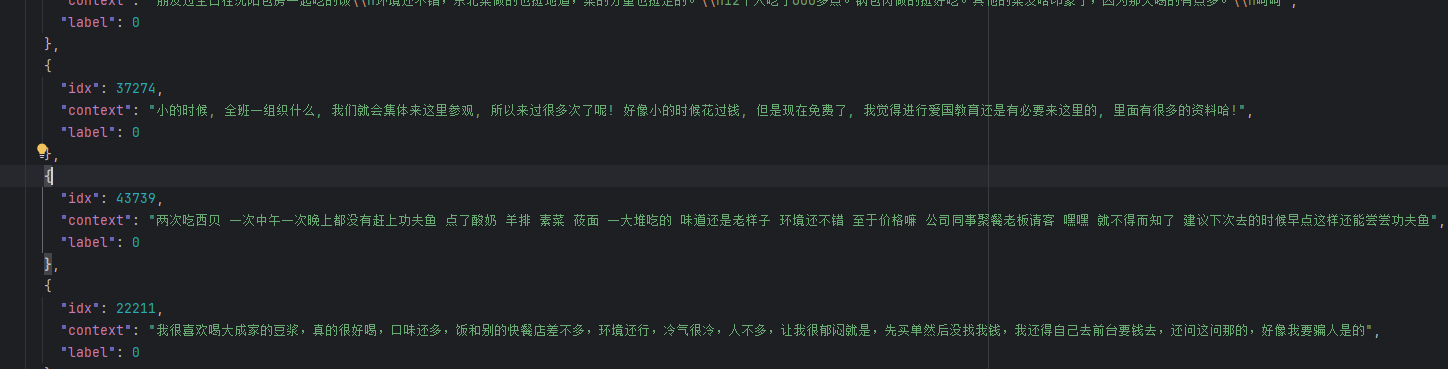
2. 模型架构：虽然换了一个模型，但可能新的模型架构不适合当前任务，或者模型过于复杂导致过拟合，或者模型过于简单导致欠拟合。
3. 超参数设置：可能在训练过程中，学习率、批量大小、训练轮数等超参数设置不合理，导致模型无法有效学习。
4. 训练过程：可能在训练过程中，数据预处理、损失函数选择、优化器选择等方面存在问题，导致模型无法收敛或者收敛到一个较差的局部最优解。

# 奖励模型太难训练了
